***Artificial Intelligence and Machine Learning.
Implementation of Convolutional Neural Network using Keras.***

***Task 1: Data Understanding & Visualization***

***Check Structure***

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import random
from sklearn.metrics import classification_report

In [16]:
from google.colab import files
uploaded = files.upload()

import zipfile

with zipfile.ZipFile("FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

Saving FruitinAmazon.zip to FruitinAmazon.zip


In [17]:
base_dir = "/content/dataset/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")

In [18]:
class_names = os.listdir(train_dir)
print("Classes:", class_names)

Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


***Display one image from each class***

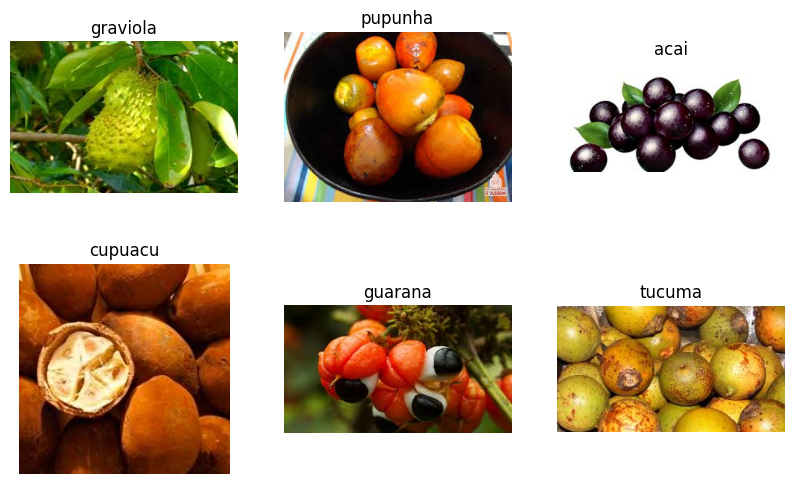

In [19]:
plt.figure(figsize=(10,6))

for i, class_name in enumerate(class_names[:6]):  # 6 images
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [20]:
corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed:", img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


***Task 2: Load & Preprocess Data***

In [21]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [22]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [23]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

***Task 3: Build CNN Model***

In [24]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


***Task 4: Compile Model***

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

***Task 5: Train Model***

In [26]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.2106 - loss: 2.9248

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 624ms/step - accuracy: 0.1944 - loss: 3.4217 - val_accuracy: 0.2222 - val_loss: 1.8052
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.2020 - loss: 1.8164

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - accuracy: 0.1528 - loss: 1.8447 - val_accuracy: 0.2778 - val_loss: 1.7326
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.2257 - loss: 1.7060

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.2083 - loss: 1.7009 - val_accuracy: 0.2778 - val_loss: 1.6535
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.3252 - loss: 1.5820

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 593ms/step - accuracy: 0.3194 - loss: 1.5819 - val_accuracy: 0.3333 - val_loss: 1.5790
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.6047 - loss: 1.4583

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.6111 - loss: 1.4286 - val_accuracy: 0.4444 - val_loss: 1.5008
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 862ms/step - accuracy: 0.6389 - loss: 1.2000 - val_accuracy: 0.3889 - val_loss: 1.5147
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.6603 - loss: 0.9676

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - accuracy: 0.6528 - loss: 0.9784 - val_accuracy: 0.4444 - val_loss: 1.4615
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.7917 - loss: 0.7577 - val_accuracy: 0.4444 - val_loss: 1.6579
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8258 - loss: 0.5965

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.8056 - loss: 0.6193 - val_accuracy: 0.5000 - val_loss: 1.2983
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.9028 - loss: 0.3866 - val_accuracy: 0.4444 - val_loss: 1.4379
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.9306 - loss: 0.2968 - val_accuracy: 0.5000 - val_loss: 1.6891
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 730ms/step - accuracy: 0.9583 - loss: 0.2181 - val_accuracy: 0.5556 - val_loss: 1.9103
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 585ms/step - accuracy: 0.9722 - loss: 0.1720 - val_accuracy: 0.3889 - val_loss: 1.3904
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 1.0000 - loss: 0.0771 - val_accuracy: 0.5556 - val_loss: 1.3311


***Task 6: Evaluate Model***

In [27]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5556 - loss: 1.3311
Accuracy: 0.5555555820465088


***Task 7: Save & Load Model***

In [28]:
model.save("final_model.h5")

loaded_model = keras.models.load_model("final_model.h5")

***Predictions + Classification Report***

In [30]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
              precision    recall  f1-score   support

    graviola       1.00      1.00      1.00         1
     pupunha       0.25      0.50      0.33         2
        acai       1.00      0.67      0.80         3
     cupuacu       0.67      0.80      0.73         5
     guarana       0.50      0.25      0.33         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.56        18
   macro avg       0.62      0.59      0.59        18
weighted avg       0.60      0.56      0.56        18



In [31]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
              precision    recall  f1-score   support

    graviola       1.00      1.00      1.00         1
     pupunha       0.25      0.50      0.33         2
        acai       1.00      0.67      0.80         3
     cupuacu       0.67      0.80      0.73         5
     guarana       0.50      0.25      0.33         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.56        18
   macro avg       0.62      0.59      0.59        18
weighted avg       0.60      0.56      0.56        18

